In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import os

## Load data

In [ ]:
attributes_df = pd.read_csv("../data/raw/citywide/image_attributes_manifest.csv")

In [3]:
attributes_df.columns

Index(['image_path', 'file_exists', 'status', 'bytes', 'asset_id',
       'profile_id', 'profile_name', 'name', 'description', 'file_id',
       'filename', 'mime_type', 'service_date', 'historical_cost',
       'valuation_cost', 'is_disposed', 'updated', 'attr_Abutment Material',
       'attr_Adjacent Slope', 'attr_Area', 'attr_Bldg Number of Months in Use',
       'attr_Bridge Type', 'attr_Cross Slope Average', 'attr_Cross Slope Max',
       'attr_Decking Material', 'attr_Distance Between Benches',
       'attr_Fall Height', 'attr_GIS ID', 'attr_Has Edge Guard',
       'attr_Has Pedestrian Railing', 'attr_Has Pedestrian Walkway',
       'attr_Height', 'attr_Last Inspection by Qualified Professional',
       'attr_Length', 'attr_Load Capacity', 'attr_Manufacturer',
       'attr_Material (Frame, Tank, Body)',
       'attr_Next Inspection by Qualified Professional',
       'attr_Next Inspection by Staff', 'attr_Number of Steps',
       'attr_Obstacle Max Height', 'attr_PO2026 Agrmt Prio

### Keeping only necessary columns

In [4]:
attributes_df = attributes_df[[
    "image_path",
    "file_exists", 
    "asset_id", 
    "profile_id",
    "profile_name",
    "description",
    "file_id",
    "filename",
    "attr_Abutment Material",
    "attr_Bridge Type",
    "attr_Decking Material",
    "attr_Fall Height",
    "attr_Has Edge Guard",
    "attr_Has Pedestrian Railing",
    "attr_Length",
    "attr_Material (Frame, Tank, Body)",
    "attr_Number of Steps",
    "attr_Structure Material",
    "attr_Structure Position",
    "attr_Width"
]]

In [5]:
attributes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5562 entries, 0 to 5561
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   image_path                         5562 non-null   object 
 1   file_exists                        5562 non-null   bool   
 2   asset_id                           5562 non-null   int64  
 3   profile_id                         5562 non-null   int64  
 4   profile_name                       5562 non-null   object 
 5   description                        5138 non-null   object 
 6   file_id                            5562 non-null   int64  
 7   filename                           5562 non-null   object 
 8   attr_Abutment Material             2094 non-null   object 
 9   attr_Bridge Type                   2054 non-null   object 
 10  attr_Decking Material              4359 non-null   object 
 11  attr_Fall Height                   5499 non-null   float

In [6]:
attributes_df.describe(include='all')

,image_path,file_exists,asset_id,profile_id,profile_name,description,file_id,filename,attr_Abutment Material,attr_Bridge Type,attr_Decking Material,attr_Fall Height,attr_Has Edge Guard,attr_Has Pedestrian Railing,attr_Length,"attr_Material (Frame, Tank, Body)",attr_Number of Steps,attr_Structure Material,attr_Structure Position,attr_Width
count,5562,5562,5562.000000,5562.00000,5562,5138,5562.000000,5562,2094,2054,4359,5499.000000,3144,5439,5278,1958,1090.000000,4355,1321,4156
unique,5562,2,NaN,NaN,5,2709,NaN,5495,7,7,7,NaN,3,7,318,12,NaN,6,4,96
top,data/citywide/images/337/48117/86997__AST_EX_2...,True,NaN,NaN,Boardwalk < 1.2m High,"2"" rough cedar boardwalk on Cedar stringers",NaN,image.png,Timber,Beam,Timber,NaN,No,No railings,0,Timber/Wood,NaN,Timber,At-Grade,1
freq,1,5310,NaN,NaN,2096,108,NaN,17,830,1162,3198,NaN,2696,3662,918,989,NaN,2716,715,1215
mean,NaN,NaN,93610.365876,317.87073,NaN,NaN,52241.341244,NaN,NaN,NaN,NaN,-0.732606,NaN,NaN,NaN,NaN,-0.100000,NaN,NaN,NaN
std,NaN,NaN,22836.986596,61.30621,NaN,NaN,25182.601794,NaN,NaN,NaN,NaN,3.147281,NaN,NaN,NaN,NaN,5.286129,NaN,NaN,NaN
min,NaN,NaN,46340.000000,253.00000,NaN,NaN,34.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
25%,NaN,NaN,83988.500000,253.00000,NaN,NaN,27318.250000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
50%,NaN,NaN,94317.500000,337.00000,NaN,NaN,57405.500000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
75%,NaN,NaN,111476.000000,356.00000,NaN,NaN,72588.750000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN


In [7]:
print("Missing values:\n", attributes_df.isnull().sum())

Missing values:
 image_path                              0
file_exists                             0
asset_id                                0
profile_id                              0
profile_name                            0
description                           424
file_id                                 0
filename                                0
attr_Abutment Material               3468
attr_Bridge Type                     3508
attr_Decking Material                1203
attr_Fall Height                       63
attr_Has Edge Guard                  2418
attr_Has Pedestrian Railing           123
attr_Length                           284
attr_Material (Frame, Tank, Body)    3604
attr_Number of Steps                 4472
attr_Structure Material              1207
attr_Structure Position              4241
attr_Width                           1406
dtype: int64


### Assigning relevant attributes to asset categories

In [8]:
PROFILE_ATTRS = {
    "Boardwalk < 1.2m High": {
        "profile_id": 337,
        "attrs": [
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Edge Guard",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Width",
        ]
    },
    "Boardwalk > 1.2m High": {
        "profile_id": 573,
        "attrs": [
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Edge Guard",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Width",
        ]
    },
    "Stairs": {
        "profile_id": 356,
        "attrs": [
            "attr_Fall Height",
            "attr_Has Pedestrian Railing",
            "attr_Material (Frame, Tank, Body)",
            "attr_Number of Steps",
            "attr_Structure Position",
        ]
    },
    "Trail Bridge": {
        "profile_id": 253,
        "attrs": [
            "attr_Abutment Material",
            "attr_Bridge Type",
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Width"
        ]
    },
    "Viewing Platform": {
        "profile_id": 359,
        "attrs": [
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Edge Guard",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Structure Position",
            "attr_Width",
        ]
    }
}

### Possible values for each attribute

In [9]:
attr_cols = [c for c in attributes_df.columns if c.startswith("attr_")]

for col in attr_cols:
    if attributes_df[col].dtype == "object":
        print(f"\n{col}:\n  {sorted(attributes_df[col].dropna().unique().tolist())}")
    else:
        print(f"\n{col}:\n  min={attributes_df[col].min()}, values={sorted(attributes_df[col].dropna().unique().tolist())}")


attr_Abutment Material:
  ['Aluminum Sill Fill', 'Composite', 'Concrete', 'Gabions', 'Steel', 'TBD', 'Timber']

attr_Bridge Type:
  ['Beam', 'Fallen Tree', 'Other', 'Suspension', 'TBD', 'TBD | Beam', 'Truss']

attr_Decking Material:
  ['Aluminum', 'Asphalt', 'Composite', 'Concrete', 'Steel', 'TBD', 'Timber']

attr_Fall Height:
  min=-1.0, values=[-1.0, 0.0, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.55, 0.6, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.55, 1.7, 1.85, 2.0, 2.4, 2.5, 2.6, 2.65, 3.0, 3.2, 3.9, 4.0, 5.5, 6.0, 9.0, 10.0, 18.0, 20.0, 125.0]

attr_Has Edge Guard:
  ['No', 'TBD', 'Yes']

attr_Has Pedestrian Railing:
  ['1 railing', '2 railings', 'No', 'No railings', 'TBD', 'TBD | No railings', 'TBD | Yes']

attr_Length:
  ['-1', '0', '0.00', '0.5', '1', '1.00', '1.38', '1.5', '1.50', '1.52', '1.7', '1.8', '1.83', '1.9', '10', '10.00', '10.2', '10.5', '10.668', '10.7', '100', '100.00', '1000', '104', '105', '106.70', '10m', '11', '11.00', '11.42', '11.7', '110', '112', '115', '118', '12', '12.0

### Creating function to remove invalid values for each attribute

In [10]:
MISSING_SENTINELS = {0.0, -1.0}  # numeric sentinels only, strings handled below

def is_valid(val):
    if pd.isna(val):
        return False
    if isinstance(val, str):
        val_stripped = val.strip()
        # Any value containing "TBD" is invalid
        if "TBD" in val_stripped.upper():
            return False
        # String representations of 0 or -1 (e.g. "0", "0.00", "-1", "-1.0")
        try:
            if float(val_stripped) in MISSING_SENTINELS:
                return False
        except ValueError:
            pass
    # Numeric 0 or -1
    if val in MISSING_SENTINELS:
        return False
    return True

In [ ]:
# Directory for plot exports
output_dir = "../reports/report_images"
os.makedirs(output_dir, exist_ok=True)

### Valid attribute fill rate per asset category

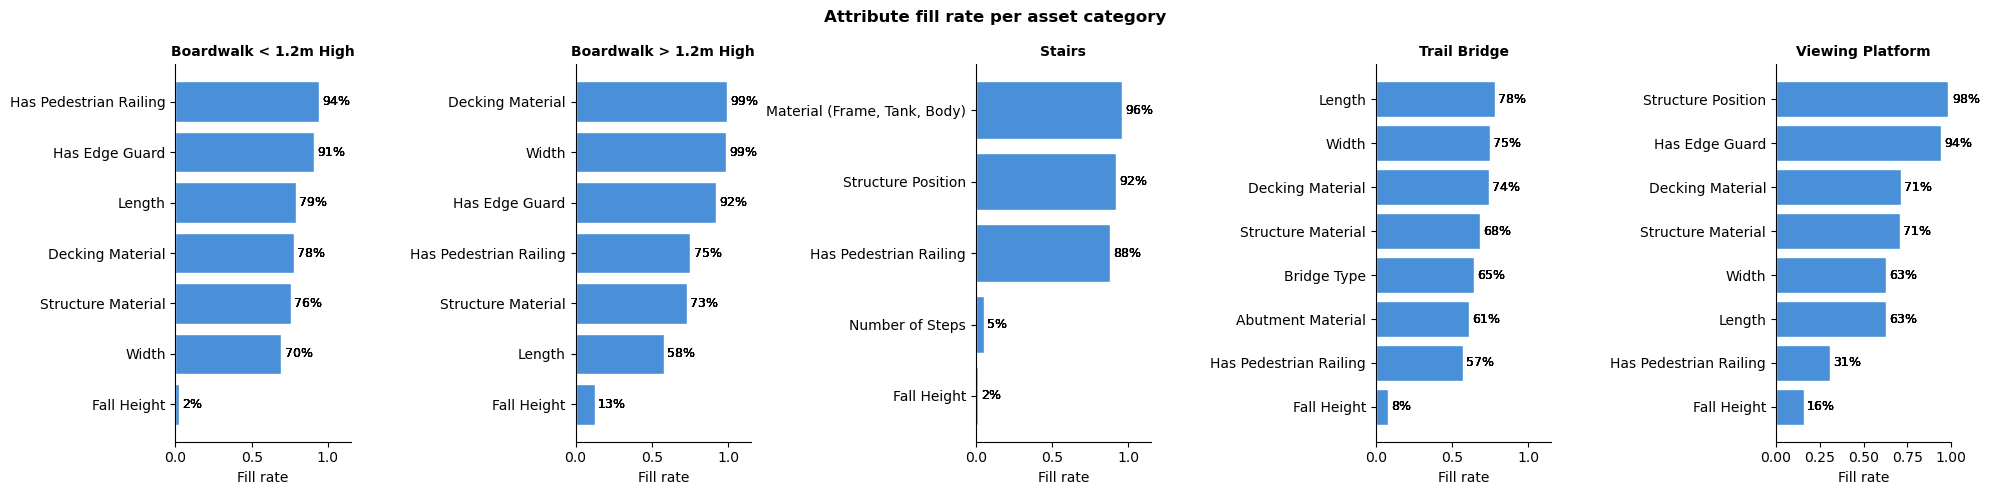

In [11]:
records = []

for category, info in PROFILE_ATTRS.items():
    subset = attributes_df[attributes_df["profile_name"] == category]
    for col in info["attrs"]:
        records.append({
            "category": category,
            "attr": col.replace("attr_", ""),
            "fill_rate": subset[col].apply(is_valid).mean(),
        })

fill_df = pd.DataFrame(records)

categories = list(PROFILE_ATTRS.keys())
fig, axes = plt.subplots(1, len(categories), figsize=(4 * len(categories), 5))

for ax, category in zip(axes, categories):
    data = fill_df[fill_df["category"] == category].sort_values("fill_rate")
    colors = "#4a90d9"
    ax.barh(data["attr"], data["fill_rate"], color=colors, edgecolor="white")
    for ax, category in zip(axes, categories):
        data = fill_df[fill_df["category"] == category].sort_values("fill_rate")
        ax.barh(data["attr"], data["fill_rate"], color="#4a90d9", edgecolor="white")
        
        # Add percentage labels
        for val, patch in zip(data["fill_rate"], ax.patches):
            ax.text(patch.get_width() + 0.02, patch.get_y() + patch.get_height() / 2,
                    f"{val:.0%}", va="center", fontsize=9)

        ax.set_xlim(0, 1.15)  # extend xlim slightly to make room for labels
        ax.set_title(category, fontsize=10, fontweight="bold")
        ax.set_xlabel("Fill rate")
        ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, 1)
    ax.set_title(category, fontsize=10, fontweight="bold")
    ax.set_xlabel("Fill rate")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Attribute fill rate per asset category", fontweight="bold")
plt.tight_layout()
plt.show()

### Class distributions per attribute

In [12]:
attributes_df["attr_Length"] = attributes_df["attr_Length"].str.replace("m", "", regex=False).pipe(pd.to_numeric, errors="coerce")
attributes_df["attr_Width"] = attributes_df["attr_Width"].str.replace("m", "", regex=False).pipe(pd.to_numeric, errors="coerce")

In [13]:
num_attrs = ["attr_Fall Height", "attr_Number of Steps", "attr_Length", "attr_Width"]
cat_attrs = [col for col in attr_cols if col not in num_attrs]

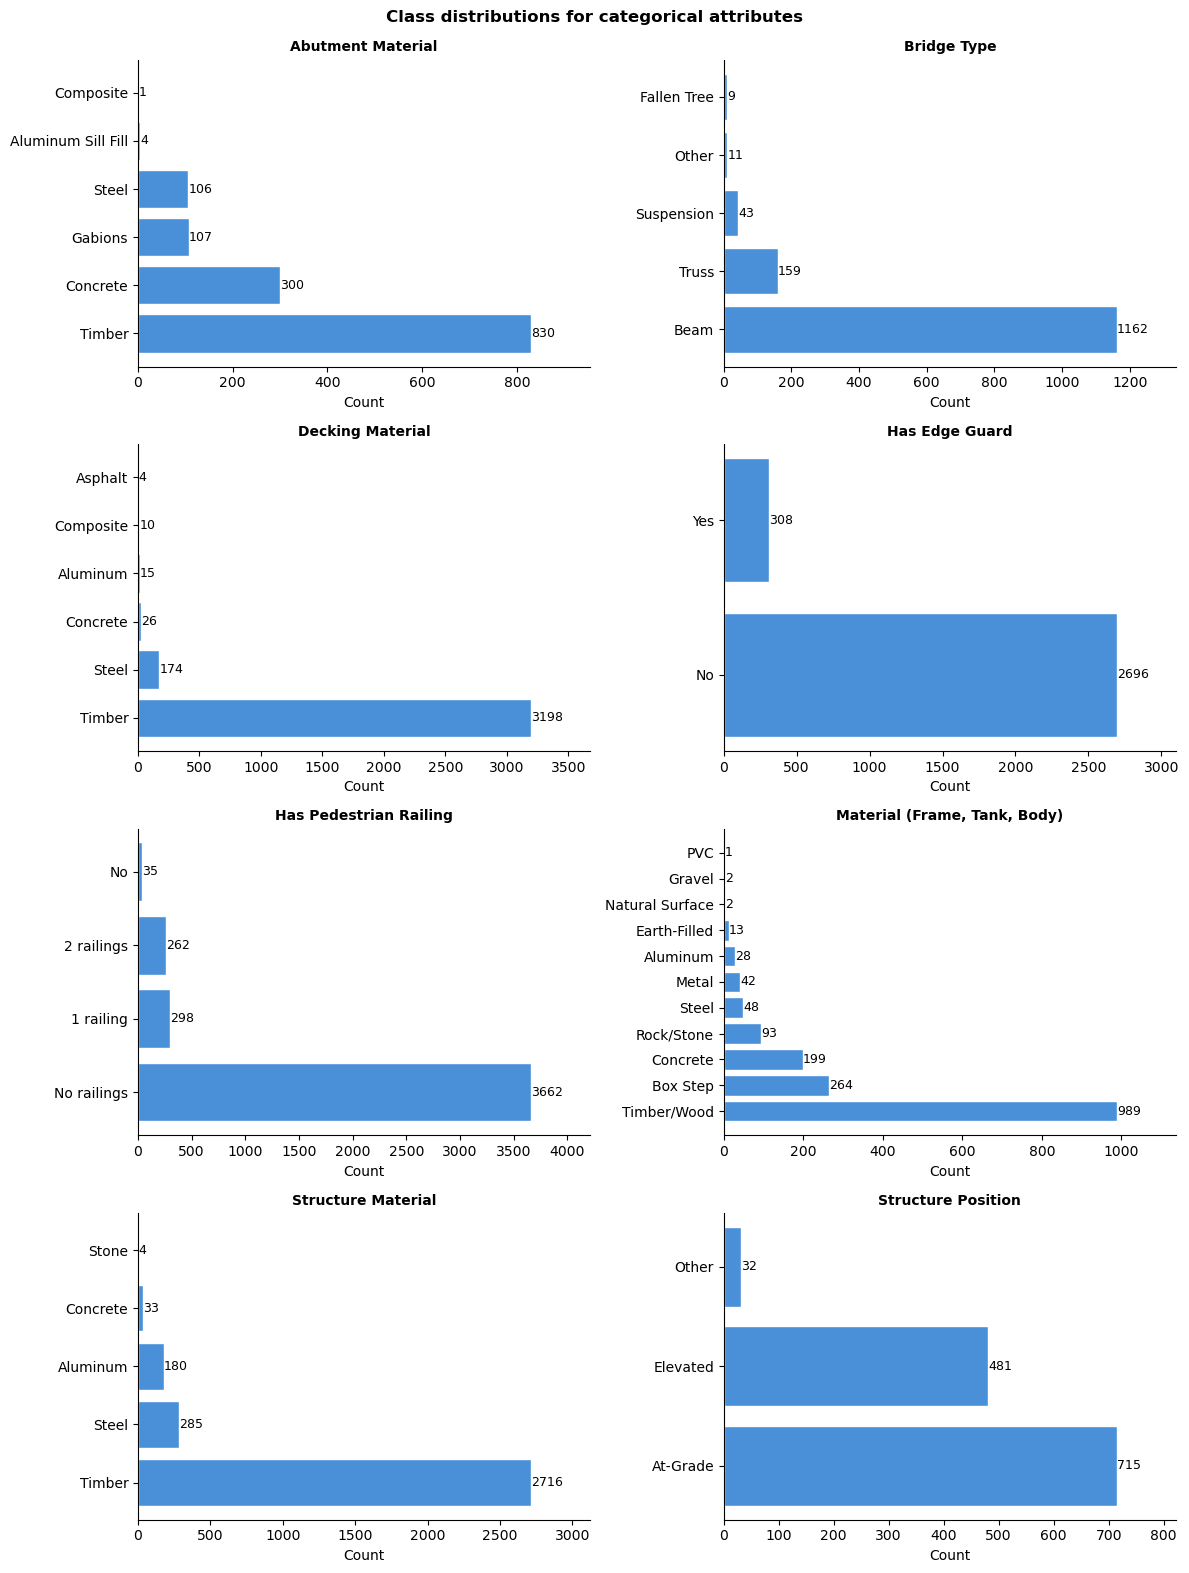

In [14]:
import math
import numpy as np

ncols = 2
nrows = math.ceil(len(cat_attrs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 4))
axes = np.array(axes).flatten().tolist()

for ax, col in zip(axes, cat_attrs):
    valid_vals = attributes_df[col][attributes_df[col].apply(is_valid)]
    counts = valid_vals.value_counts()

    if counts.empty:
        ax.set_visible(False)
        continue

    bars = ax.barh(counts.index.astype(str), counts.values, color="#4a90d9", edgecolor="white")

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=9)

    ax.set_title(col.replace("attr_", ""), fontsize=10, fontweight="bold")
    ax.set_xlabel("Count")
    ax.set_xlim(0, counts.values.max() * 1.15)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(cat_attrs):]:
    ax.set_visible(False)

fig.suptitle("Class distributions for categorical attributes\n", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

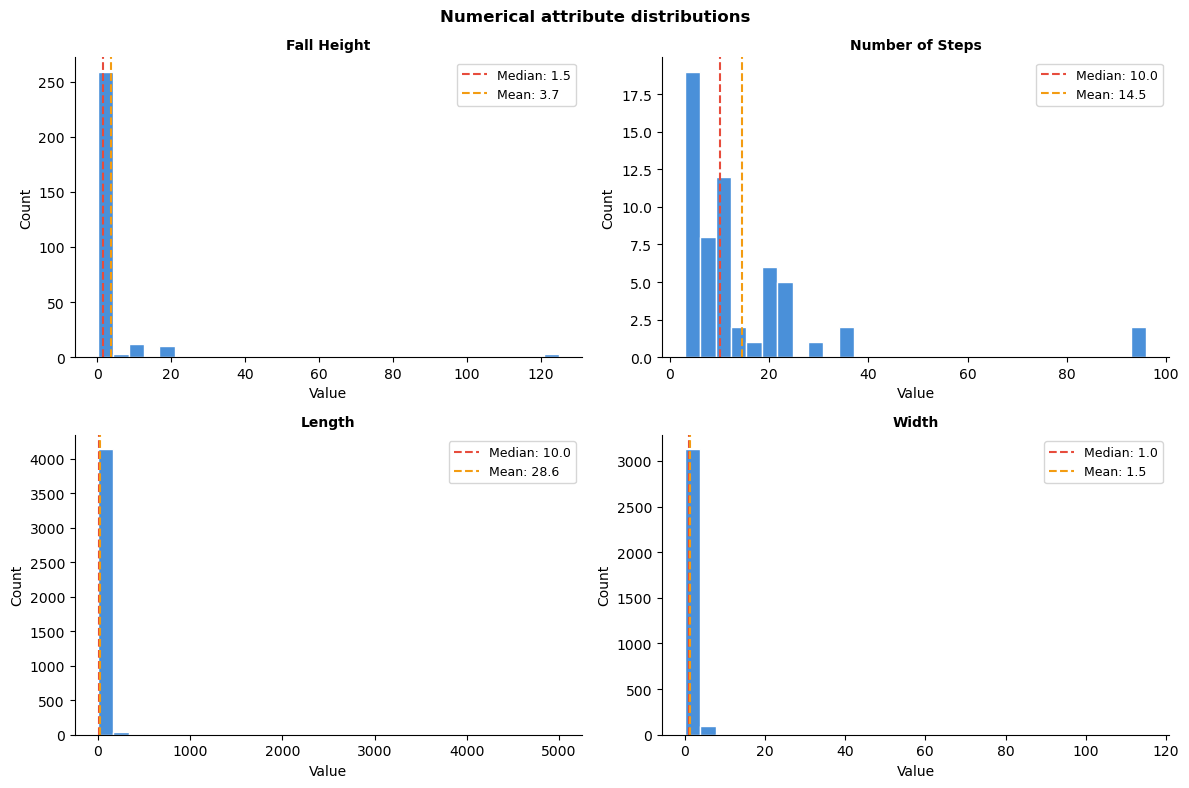

In [15]:
ncols = 2
nrows = math.ceil(len(num_attrs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 4))
axes = np.array(axes).flatten().tolist()

for ax, col in zip(axes, num_attrs):
    valid_vals = attributes_df[col][attributes_df[col].apply(is_valid)].dropna()

    ax.hist(valid_vals, bins=30, color="#4a90d9", edgecolor="white")
    ax.axvline(valid_vals.median(), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Median: {valid_vals.median():.1f}")
    ax.axvline(valid_vals.mean(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mean: {valid_vals.mean():.1f}")
    ax.set_title(col.replace("attr_", ""), fontsize=10, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(num_attrs):]:
    ax.set_visible(False)

fig.suptitle("Numerical attribute distributions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## More Data Exploration/Cleaning

In [16]:
print("---COUNTS---")
print("Total images:", len(attributes_df))
print("Unique asset IDs:", attributes_df["asset_id"].nunique())
print("Avg images per asset:", len(attributes_df) / attributes_df["asset_id"].nunique())
print("Max images per asset:", attributes_df.groupby("asset_id")["filename"].count().max())
print("Min images per asset:", attributes_df.groupby("asset_id")["filename"].count().min())

---COUNTS---
Total images: 5562
Unique asset IDs: 3584
Avg images per asset: 1.5518973214285714
Max images per asset: 10
Min images per asset: 1


In [17]:
print("Unique asset IDs:", attributes_df["asset_id"].nunique())
print("Images per asset:")
print(attributes_df.groupby("asset_id")["filename"].count().describe())

Unique asset IDs: 3584
Images per asset:
count    3584.000000
mean        1.551897
std         1.175424
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: filename, dtype: float64


In [18]:
print("Assets with missing asset_id:", attributes_df["asset_id"].isna().sum())

Assets with missing asset_id: 0


In [19]:
no_asset = attributes_df[attributes_df["asset_id"].isna()]
print(f"Images with no asset ID: {len(no_asset)}")
print(no_asset["filename"].tolist())

Images with no asset ID: 0
[]


In [20]:
duplicates = attributes_df[attributes_df["filename"].duplicated(keep=False)]
print(f"Duplicate images: {len(duplicates)}")
print(duplicates[["filename", "asset_id", "profile_id"]])


Duplicate images: 101
                         filename  asset_id  profile_id
611                  IMG_0669.JPG     89710         337
894   AST_IM_20211013_102444.jpeg     92006         337
987                  IMG_0052.JPG     94269         337
1014                 IMG_0180.JPG     94300         337
1015                 IMG_0192.JPG     94303         337
...                           ...       ...         ...
5322   GetAttachmentThumbnail.jpg    128830         253
5324   GetAttachmentThumbnail.jpg    128831         253
5429                    image.png     57509         359
5430                    image.png     57509         359
5431                    image.png     57509         359

[101 rows x 3 columns]


In [ ]:
#same image appears in multiple asset type folders
multi_folder = attributes_df.groupby("filename")["profile_id"].nunique()
print(f"\nImages in multiple folders: {(multi_folder > 1).sum()}")
print(multi_folder[multi_folder > 1])


Images in multiple folders: 10
filename
AST_IM_20211013_102444.jpeg    2
AST_IM_20220721_122330.jpeg    2
AST_IM_20220726_120244.jpeg    2
IMG_0052.JPG                   2
IMG_0180.JPG                   2
IMG_0192.JPG                   2
New stairs.jpg                 2
bridge1.jpg                    2
bridge3.jpg                    2
image.png                      3
Name: profile_id, dtype: int64


In [ ]:
#from the above, i did manual checks of duplicates and they are not the same image
#more reliable column to check for duplicates is file_id. 
# sometimes there are same filename for images but different file id at the start, which signals they are different images
dup_by_id = attributes_df[attributes_df["file_id"].duplicated(keep=False)]
print(f"Duplicate file IDs: {len(dup_by_id)}")
print(dup_by_id[["filename", "asset_id", "file_id"]])

Duplicate file IDs: 0
Empty DataFrame
Columns: [filename, asset_id, file_id]
Index: []


In [ ]:
#confirms no image has same file id + filename - no duplicate images present
dup_both = attributes_df[attributes_df.duplicated(subset=["file_id", "filename"], keep=False)]
print(f"Duplicates by file_id + filename: {len(dup_both)}")

Duplicates by file_id + filename: 0


In [24]:
#verifying we only have necessary cols
print("Current columns:")
print(attributes_df.columns.tolist())

Current columns:
['image_path', 'file_exists', 'asset_id', 'profile_id', 'profile_name', 'description', 'file_id', 'filename', 'attr_Abutment Material', 'attr_Bridge Type', 'attr_Decking Material', 'attr_Fall Height', 'attr_Has Edge Guard', 'attr_Has Pedestrian Railing', 'attr_Length', 'attr_Material (Frame, Tank, Body)', 'attr_Number of Steps', 'attr_Structure Material', 'attr_Structure Position', 'attr_Width']


### Standardizing Column names

In [ ]:
#no spaces in col names, only underscores
attributes_df.columns = (
    attributes_df.columns
    .str.strip()          
    .str.lower()  
    .str.replace(" ", "_") 
    .str.replace("(", "") 
    .str.replace(")", "")
    .str.replace("/", "_")
    .str.replace("-", "_")
)

In [26]:
print(attributes_df.columns.tolist())

['image_path', 'file_exists', 'asset_id', 'profile_id', 'profile_name', 'description', 'file_id', 'filename', 'attr_abutment_material', 'attr_bridge_type', 'attr_decking_material', 'attr_fall_height', 'attr_has_edge_guard', 'attr_has_pedestrian_railing', 'attr_length', 'attr_material_frame,_tank,_body', 'attr_number_of_steps', 'attr_structure_material', 'attr_structure_position', 'attr_width']


In [ ]:
# redefine which attributes apply to each asset type
ASSET_ATTRIBUTES = {
    "Boardwalk < 1.2m High": ["attr_decking_material", "attr_fall_height", "attr_has_edge_guard", 
                               "attr_has_pedestrian_railing", "attr_length", 
                               "attr_structure_material", "attr_width"],
    
    "Boardwalk > 1.2m High": ["attr_decking_material", "attr_fall_height", "attr_has_edge_guard",
                               "attr_has_pedestrian_railing", "attr_length",
                               "attr_structure_material", "attr_width"],
    
    "Stairs": ["attr_fall_height", "attr_has_pedestrian_railing", 
               "attr_material_frame,_tank,_body", "attr_number_of_steps",
               "attr_structure_position"],
    
    "Trail Bridge": ["attr_abutment_material", "attr_bridge_type", "attr_decking_material",
                     "attr_fall_height", "attr_has_pedestrian_railing", "attr_length",
                     "attr_structure_material", "attr_width"],
    
    "Viewing Platform": ["attr_decking_material", "attr_fall_height", "attr_has_edge_guard",
                          "attr_has_pedestrian_railing", "attr_length",
                          "attr_structure_material", "attr_structure_position", "attr_width"]
}

# inspect all value distributions per asset type
for asset_type, cols in ASSET_ATTRIBUTES.items():
    print(f"\n{'='*60}")
    print(f"ASSET TYPE: {asset_type}")
    subset = attributes_df[attributes_df["profile_name"] == asset_type]
    print(f"Total rows: {len(subset)}")
    
    for col in cols:
        if col in attributes_df.columns:
            n_unique = subset[col].nunique()
            print(f"\n  {col} — {n_unique} unique values")
            
            if n_unique <= 30:
                print(subset[col].value_counts(dropna=False).to_string())
            else:
                print(subset[col].describe()[["count", "min", "mean", "max"]])


ASSET TYPE: Boardwalk < 1.2m High
Total rows: 2096

  attr_decking_material — 5 unique values
attr_decking_material
Timber       1578
TBD           373
NaN            95
Steel          48
Aluminum        1
Composite       1

  attr_fall_height — 12 unique values
attr_fall_height
-1.00    1991
 0.00      46
 0.50      13
 NaN        9
 1.00       8
 0.10       6
 0.20       6
 1.50       6
 0.25       3
 0.30       2
 0.60       2
 0.40       2
 1.40       2

  attr_has_edge_guard — 3 unique values
attr_has_edge_guard
No     1861
NaN     180
Yes      42
TBD      13

  attr_has_pedestrian_railing — 4 unique values
attr_has_pedestrian_railing
No railings    1931
NaN              79
TBD              45
No               32
1 railing         9

  attr_length — 166 unique values
count    1913.000000
min        -1.000000
mean       41.660879
max      5000.000000
Name: attr_length, dtype: float64

  attr_structure_material — 5 unique values
attr_structure_material
Timber      1561
TBD         

In [ ]:
#manually inspecting numerical outliers (unusually large numbers for fall height?)
fall_height_outliers = attributes_df[attributes_df["attr_fall_height"] > 10][
    ["asset_id", "profile_id", "filename", "profile_name", "attr_fall_height"]
]
print("Fall height outliers:")
print(fall_height_outliers)

length_outliers = attributes_df[attributes_df["attr_length"] > 500][
    ["asset_id", "profile_id", "filename", "profile_name", "attr_length"]
]
print("\nLength outliers:")
print(length_outliers)

Fall height outliers:
      asset_id  profile_id                     filename      profile_name  \
3500     51798         253  AST_EX_20210719_112242.jpeg      Trail Bridge   
3501     51798         253  AST_EX_20241128_121359.jpeg      Trail Bridge   
3502     51798         253  AST_EX_20241128_121253.jpeg      Trail Bridge   
3503     51798         253  AST_EX_20241128_121213.jpeg      Trail Bridge   
3504     51798         253  AST_EX_20241128_121243.jpeg      Trail Bridge   
3505     51798         253  AST_EX_20241128_121412.jpeg      Trail Bridge   
3507     51798         253  AST_EX_20241128_121149.jpeg      Trail Bridge   
5434     58829         359  AST_EX_20231214_122401.jpeg  Viewing Platform   
5435     58829         359  AST_EX_20241028_154517.jpeg  Viewing Platform   
5436     58829         359  AST_EX_20250707_091202.jpeg  Viewing Platform   
5482     74894         359  AST_EX_20231214_121609.jpeg  Viewing Platform   
5483     74894         359  AST_EX_20241028_153355.jpe

### Standardizing Nan Values

In [31]:
#using already defined is_valid function from EDA

attribute_cols = [col for col in attributes_df.columns if col.startswith("attr_")]

for col in attribute_cols:
    attributes_df[col] = attributes_df[col].apply(
        lambda x: x if is_valid(x) else np.nan
    )

print("After cleaning - NaN counts per attribute:")
print(attributes_df[attribute_cols].isna().sum())

After cleaning - NaN counts per attribute:
attr_abutment_material             4214
attr_bridge_type                   4178
attr_decking_material              2135
attr_fall_height                   5275
attr_has_edge_guard                2558
attr_has_pedestrian_railing        1305
attr_length                        1343
attr_material_frame,_tank,_body    3881
attr_number_of_steps               5504
attr_structure_material            2344
attr_structure_position            4334
attr_width                         2311
dtype: int64


In [ ]:
# standardizing values of has_pedestrian_railing attribute
railing_mapping = {
    "No": "No railings",
    "No railings": "No railings",
    "1 railing": "1 railing",
    "2 railings": "2 railings"
}
attributes_df["attr_has_pedestrian_railing"] = (
    attributes_df["attr_has_pedestrian_railing"].map(railing_mapping)
)

print(attributes_df["attr_has_pedestrian_railing"].value_counts(dropna=False))

attr_has_pedestrian_railing
No railings    3697
NaN            1305
1 railing       298
2 railings      262
Name: count, dtype: int64


In [ ]:
#checking values after standardizing nan values across columns

attr_cols = [c for c in attributes_df.columns if c.startswith("attr_")]

for col in attr_cols:
    if attributes_df[col].dtype == "object":
        print(f"\n{col}:\n  {sorted(attributes_df[col].dropna().unique().tolist())}")
    else:
        print(f"\n{col}:\n  min={attributes_df[col].min()}, values={sorted(attributes_df[col].dropna().unique().tolist())}")


attr_abutment_material:
  ['Aluminum Sill Fill', 'Composite', 'Concrete', 'Gabions', 'Steel', 'Timber']

attr_bridge_type:
  ['Beam', 'Fallen Tree', 'Other', 'Suspension', 'Truss']

attr_decking_material:
  ['Aluminum', 'Asphalt', 'Composite', 'Concrete', 'Steel', 'Timber']

attr_fall_height:
  min=0.1, values=[0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.55, 0.6, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.55, 1.7, 1.85, 2.0, 2.4, 2.5, 2.6, 2.65, 3.0, 3.2, 3.9, 4.0, 5.5, 6.0, 9.0, 10.0, 18.0, 20.0, 125.0]

attr_has_edge_guard:
  ['No', 'Yes']

attr_has_pedestrian_railing:
  ['1 railing', '2 railings', 'No railings']

attr_length:
  min=0.5, values=[0.5, 1.0, 1.38, 1.5, 1.52, 1.7, 1.8, 1.83, 1.9, 2.0, 2.1, 2.2, 2.25, 2.3, 2.34, 2.4, 2.4384, 2.44, 2.45, 2.5, 2.6, 2.7, 2.75, 2.8, 2.9, 2.95, 3.0, 3.048, 3.05, 3.1, 3.16, 3.2, 3.25, 3.4, 3.5, 3.6, 3.64, 3.7, 3.75, 3.82, 3.9, 3.98, 4.0, 4.1, 4.2, 4.27, 4.3, 4.4, 4.46, 4.5, 4.57, 4.572, 4.6, 4.8, 4.8768, 4.877, 4.88, 5.0, 5.1, 5.16, 5.18, 5.182, 5.2, 5.25, 5.3

### Filtering for length measured by staff only - copilot values will not be used as ground truth for training purposes

In [42]:
old_attachments = pd.read_excel("../data/raw/citywide/Capstone_Assets_Attributes_FileAttachments_recent.xlsx", sheet_name="attachments")

print("Old:", len(old_attachments))
print("New CSV:", len(attributes_df))

old_filenames = set(old_attachments["File Name"].tolist())
new_filenames = set(attributes_df["filename"].tolist())


extra = attributes_df[~attributes_df["filename"].isin(old_filenames)]
print(f"New rows: {len(extra)}")
print(extra[["asset_id", "filename", "profile_name"]])

Old: 5561
New CSV: 5562
New rows: 102
      asset_id                     filename           profile_name
146      65430  AST_EX_20210916_163423.jpeg  Boardwalk < 1.2m High
164      83121  AST_IM_20210708_113124.jpeg  Boardwalk < 1.2m High
165      83121  AST_IM_20210708_113117.jpeg  Boardwalk < 1.2m High
444      86329  AST_IM_20210812_123228.jpeg  Boardwalk < 1.2m High
446      86329  AST_EX_20251019_143317.jpeg  Boardwalk < 1.2m High
...        ...                          ...                    ...
5440     60962  AST_EX_20220407_152337.jpeg       Viewing Platform
5441     60962  AST_EX_20220407_152320.jpeg       Viewing Platform
5442     60962  AST_EX_20220407_152300.jpeg       Viewing Platform
5445     61424  AST_EX_20241024_121703.jpeg       Viewing Platform
5457     66956       MI_20210803_125548.jpg       Viewing Platform

[102 rows x 3 columns]


In [44]:
missing_from_new = old_attachments[~old_attachments["File Name"].isin(attributes_df["filename"])]
print(f"Rows in old but not in new CSV: {len(missing_from_new)}")
print(missing_from_new[["Asset ID", "File Name"]].head(20))

Rows in old but not in new CSV: 105
     Asset ID                                          File Name
229     51224  K6818 Rainbow Bridge Condition Assessment - 20...
318     51798  0836-053 - Upper Englishman River Bridge Inspe...
319     51798  0836-045 Lower Bridge Drawings with Bobcat Loa...
320     51798  0836-045 Upper Bridge Bobcat Load Assessment N...
460     53985  Inland Lake - Record Drawings - IFU - 20250311...
464     53993  Inland Lake - Record Drawings - IFU - 20250311...
489     54329                                20210529_120011.jpg
490     54329                                20210529_115955.jpg
491     54329                                20210529_120001.jpg
492     54329                                20210529_115758.jpg
493     54329                                20210529_115840.jpg
494     54329                                20210529_115742.jpg
495     54329                                20210529_115814.jpg
496     54329                                20210529_

102 rows/images that are in new attributes file, that are not in old excel file provided by Hilary. 105 in old that are not in new.

In [54]:
dupes = old_attachments[old_attachments["File Name"].duplicated(keep=False)]
print(dupes[["File Name", "Asset ID", "Length measured by staff"]].sort_values("File Name"))

                        File Name  Asset ID  Length measured by staff
4553  AST_EX_20230415_114331.jpeg    116621                      True
4554  AST_EX_20230415_114331.jpeg    116621                      True
4555  AST_EX_20230415_114331.jpeg    116621                      True
4556  AST_EX_20230415_114331.jpeg    116621                      True
4561  AST_EX_20230415_114331.jpeg    116621                      True
...                           ...       ...                       ...
922                     image.png     63066                      True
2891                    image.png     95730                      True
3493                    image.png    107140                      True
685                     image.png     57507                     False
2895                    image.png     95730                      True

[94 rows x 3 columns]


In [59]:
old_attachments_slim = (old_attachments[["File Name", "Asset ID", "Length measured by staff"]]
    .drop_duplicates(subset=["File Name", "Asset ID"], keep="first") 
    .rename(columns={"File Name": "filename", "Asset ID": "asset_id"})
)

print(f"Before: {len(old_attachments)}")
print(f"After: {len(old_attachments_slim)}")

Before: 5561
After: 5523


In [64]:
attributes_df = attributes_df.merge(
    old_attachments_slim[["filename", "asset_id", "Length measured by staff"]],
    on=["filename", "asset_id"],
    how="left"
)

print(f"Shape after merge: {attributes_df.shape}")
print("\nLength measured by staff counts:")
print(attributes_df["Length measured by staff"].value_counts(dropna=False))

Shape after merge: (5562, 21)

Length measured by staff counts:
Length measured by staff
True     3082
False    2373
NaN       107
Name: count, dtype: int64


In [65]:
# only trust length values where measured by staff
attributes_df.loc[attributes_df["Length measured by staff"] != True, "attr_length"] = np.nan

print("Length values after filtering:")
print(attributes_df["attr_length"].notna().sum(), "valid length values")

Length values after filtering:
3082 valid length values


### Binning numerical attributes

From BCParks professional inspection documentation, assets with fall height > 1.2 is when assets need to be inspected by field engineers every 5 years.

In [66]:
#checking numerical dists by asset type (same as EDA figure above)
for col in ["attr_length", "attr_width", "attr_fall_height", "attr_number_of_steps"]:
    if col in attributes_df.columns:
        print(f"\n{col}:")
        print(attributes_df.groupby("profile_name")[col].describe()[["min", "mean", "max", "count"]])


attr_length:
                       min       mean     max   count
profile_name                                         
Boardwalk < 1.2m High  0.5  47.783857  5000.0  1644.0
Boardwalk > 1.2m High  1.0  18.915319   100.0    81.0
Stairs                 2.0  10.437500   115.0    48.0
Trail Bridge           1.0  12.506963   240.0  1284.0
Viewing Platform       1.8  19.632000    30.0    25.0

attr_width:
                       min      mean     max   count
profile_name                                        
Boardwalk < 1.2m High  0.2  1.172899   42.00  1457.0
Boardwalk > 1.2m High  0.3  1.144443    3.00   148.0
Stairs                 0.6  0.817500    1.07     4.0
Trail Bridge           0.1  1.503602  115.00  1499.0
Viewing Platform       1.0  4.070699   13.00   143.0

attr_fall_height:
                        min       mean    max  count
profile_name                                        
Boardwalk < 1.2m High  0.10   0.629000    1.5   50.0
Boardwalk > 1.2m High  0.50   1.357895    2.0 

Because of the different value ranges across attributes AND assets, bins will be attribute and asset specific for now.

In [80]:
#function to generate discretized length by asset 

def bin_length(row):
    val = row["attr_length"]
    asset = row["profile_name"]
    
    if pd.isna(val):
        return np.nan
    
    if asset == "Boardwalk < 1.2m High":
        # range 0.5-5000, mean 48
        if val < 20:        return "short (<20m)"
        elif val < 100:     return "medium (20-100m)"
        else:               return "long (>100m)"
    
    elif asset == "Boardwalk > 1.2m High":
        # range 1-100, mean 19
        if val < 10:        return "short (<10m)"
        elif val < 30:      return "medium (10-30m)"
        else:               return "long (>30m)"
    
    elif asset == "Stairs":
        # range 2-115, mean 10
        if val < 5:         return "short (<5m)"
        elif val < 20:      return "medium (5-20m)"
        else:               return "long (>20m)"
    
    elif asset == "Trail Bridge":
        # range 1-240, mean 12.5
        if val < 6:         return "short (<6m)"
        elif val < 20:      return "medium (6-20m)"
        else:               return "long (>20m)"
    
    elif asset == "Viewing Platform":
        # range 1.8-30, mean 19.6
        if val < 10:        return "small (<10m)"
        elif val < 20:      return "medium (10-20m)"
        else:               return "large (>20m)"
    
    return np.nan

attributes_df["length_bin"] = attributes_df.apply(bin_length, axis=1)

In [81]:
# function to create discretized widths, specific to each asset based on above stats

def bin_width(row):
    val = row["attr_width"]
    asset = row["profile_name"]
    
    if pd.isna(val):
        return np.nan
    
    if asset == "Viewing Platform":
        # range 1-13, mean 4
        if val < 3:         return "narrow (<3m)"
        elif val < 7:       return "medium (3-7m)"
        else:               return "wide (>7m)"
    
    elif asset == "Stairs":
        # range 0.6-1.07, very narrow range
        if val < 0.8:       return "narrow (<0.8m)"
        else:               return "standard (>=0.8m)"
    
    else:
        # boardwalks and trail bridge - range 0.1-3 (excluding outliers)
        if val < 0.9:       return "narrow (<0.9m)"
        elif val < 1.5:     return "standard (0.9-1.5m)"
        else:               return "wide (>1.5m)"
    
    return np.nan

attributes_df["width_bin"] = attributes_df.apply(bin_width, axis=1)

In [82]:
# fall height bins 

def bin_fall_height(row):
    val = row["attr_fall_height"]
    asset = row["profile_name"]
    
    if pd.isna(val):
        return np.nan
    
    if asset == "Viewing Platform":
        # range 0.25-125, mean 13 — very wide range
        if val < 1.2:         return "low (<1.2m)"
        elif val < 15:      return "medium (1.2-15m)"
        else:               return "high (>15m)"
    
    elif asset == "Trail Bridge":
        # range 0.2-18, mean 3.2
        if val < 1.2:         return "low (<1.2m)"
        elif val < 5:       return "medium (1.2-5m)"
        else:               return "high (>5m)"
    
    else:
        # boardwalks and stairs - range 0.1-2, mean 0.6-1.4
        if val < 0.5:       return "low (<0.5m)"
        elif val < 1.2:     return "medium (0.5-1.2m)"
        else:               return "high (>1.2m)"
    
    return np.nan

attributes_df["fall_height_bin"] = attributes_df.apply(bin_fall_height, axis=1)

In [83]:
#number of steps : stairs only 

def bin_steps(row):
    val = row["attr_number_of_steps"]
    asset = row["profile_name"]
    
    if pd.isna(val) or asset != "Stairs":
        return np.nan
    
    if val < 10:        return "few (<10)"
    elif val < 20:      return "medium (10-20)"
    else:               return "many (>20)"

attributes_df["steps_bin"] = attributes_df.apply(bin_steps, axis=1)

In [84]:
#verifying bins 

for col in ["length_bin", "width_bin", "fall_height_bin", "steps_bin"]:
    print(f"\n{col}:")
    print(attributes_df.groupby("profile_name")[col].value_counts(dropna=False))


length_bin:
profile_name           length_bin      
Boardwalk < 1.2m High  short (<20m)        1002
                       medium (20-100m)     489
                       NaN                  452
                       long (>100m)         153
Boardwalk > 1.2m High  NaN                   69
                       short (<10m)          40
                       medium (10-30m)       25
                       long (>30m)           16
Stairs                 NaN                 1045
                       short (<5m)           22
                       medium (5-20m)        21
                       long (>20m)            5
Trail Bridge           NaN                  711
                       medium (6-20m)       673
                       short (<6m)          428
                       long (>20m)          183
Viewing Platform       NaN                  203
                       large (>20m)          15
                       medium (10-20m)        6
                       small (<10m)

In [85]:
#saving master csv. binned attributes added as separate cols, they are not replacing original numerical attribute cols
attributes_df.to_csv("../data/processed/master_dataset.csv", index=False)
print(f"Saved master: {attributes_df.shape}")

Saved master: (5562, 25)


### Saving Dataframes for each Asset Type

In [86]:
base_cols = ["asset_id", "filename", "file_id", "profile_name", "image_path"]

# defining binned cols for each asset type
bin_cols = {
    "Boardwalk < 1.2m High": ["length_bin", "width_bin", "fall_height_bin"],
    "Boardwalk > 1.2m High": ["length_bin", "width_bin", "fall_height_bin"],
    "Stairs": ["fall_height_bin", "steps_bin"],
    "Trail Bridge": ["length_bin", "width_bin", "fall_height_bin"],
    "Viewing Platform": ["length_bin", "width_bin", "fall_height_bin"]
}

In [87]:
asset_dfs = {}
for asset_type, attr_cols in ASSET_ATTRIBUTES.items():
    cols = base_cols + attr_cols + bin_cols[asset_type]
    cols_available = [c for c in cols if c in attributes_df.columns]
    
    df = attributes_df[attributes_df["profile_name"] == asset_type][cols_available].copy()
    asset_dfs[asset_type] = df
    
    filename = (asset_type.lower()
                .replace(" ", "_")
                .replace("<", "lt")
                .replace(">", "gt")
                .replace(".", ""))
    
    df.to_csv(f"../data/processed/{filename}.csv", index=False)
    print(f"{asset_type}: {len(df)} rows, {df['asset_id'].nunique()} assets")

Boardwalk < 1.2m High: 2096 rows, 1645 assets
Boardwalk > 1.2m High: 150 rows, 84 assets
Stairs: 1093 rows, 691 assets
Trail Bridge: 1995 rows, 1065 assets
Viewing Platform: 228 rows, 99 assets
